# Macaulay EQ Duration

Dieses Notebook konstruiert die **Macaulay DCF Duration auf EPS-Basis** für das EURO500-Universum.

Ziel:
- saubere Trennung zwischen **explizitem Forecast-Horizont** und **Terminalstruktur**
- transparente Formel-zu-Code-Abbildung
- nachvollziehbare Interpretation der resultierenden Duration

3 Wesentliche Schritte
1. Expliziter Forecast-Horizont (FY1-FYH)
2. Two-Stage Terminal Structure (Fade + Perpetuity)
3. Aggregation zur Macaulay Duration


## 1) Setup und Modellparameter

In diesem Block definiere ich den Datenpfad und die ökonomischen Konstanten.

Fixe Modellannahmen:
- Diskontsatz: $R = 10\%$
- Maximaler expliziter Horizont: $T=5$
- Cap für firmenspezifisches LTG: $g_i = \min(LTG_i, 5\%)$
- Langfristiges Wachstum: $g_\infty = 2\%$
- Fade-Länge: 10 Jahre

Wichtig: Für die Perpetuity muss stets gelten $R > g_\infty$.


In [18]:
from pathlib import Path
import numpy as np
import pandas as pd

BASE_DIR = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data')
DATA_DIR = BASE_DIR / 'intermediate'

R = 0.10
T = 5
G_CAP = 0.10
G_INF = 0.02
FADE_YEARS = 10

# Required for terminal value denominator (R - g_inf) in perpetuity block
if R <= G_INF:
    raise ValueError(f'Need R > g_inf. Got R={R}, g_inf={G_INF}')

print('Data dir:', DATA_DIR)
print('Parameters:', {'T': T, 'R': R, 'g_cap': G_CAP, 'g_inf': G_INF, 'fade_years': FADE_YEARS})

Data dir: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate
Parameters: {'T': 5, 'R': 0.1, 'g_cap': 0.1, 'g_inf': 0.02, 'fade_years': 10}


## 2) Input laden und verwendete Forecast-Spalten bestimmen

Ich lade die EPS-Tabelle und bestimme robust, welche Forward-Spalten verfügbar sind.

Regel:
- mind. 3 verfügbare Forecast-Jahre pro Zeile notwendig
- Ziel ist FY1-FY5; falls weniger vorhanden, wird zeilenweise ein kürzerer Horizont genutzt


In [19]:
candidate_files = [
    'euro500_EPS.parquet',
]

selected_path = None
for name in candidate_files:
    candidate = DATA_DIR / name
    if candidate.exists():
        selected_path = candidate
        break

if selected_path is None:
    raise FileNotFoundError('Keine passende Input-Tabelle gefunden (erwartet: euro500_EPS.parquet).')

df = pd.read_parquet(selected_path).copy()
print('Loaded:', selected_path)
print('Shape:', df.shape)
print('Columns (first 30):', list(df.columns)[:30])


Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_EPS.parquet
Shape: (56500, 29)
Columns (first 30): ['date', 'formation_date', 'effective_date', 'quarter', 'RIC', 'name', 'firm_id', 'hq_country', 'hq_code', 'trbc_sector', 'trbc_sector_code', 'mcap_eur', 'RIC_current', 'ISIN', 'SEDOL', 'first_trade_date', 'ipo_date', 'FreeFloat', 'FreeFloatPct', 'Volume', 'PriceClose', 'InstrumentType', 'Currency', 'rank_mcap', 'EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5']


In [20]:
cashflow_priority = [
    # Prefer cashflow-like measures when available
    ['CFPS_FY1', 'CFPS_FY2', 'CFPS_FY3', 'CFPS_FY4', 'CFPS_FY5'],
    ['TR.CFPSMean_FY1', 'TR.CFPSMean_FY2', 'TR.CFPSMean_FY3', 'TR.CFPSMean_FY4', 'TR.CFPSMean_FY5'],
    ['NP_FY1', 'NP_FY2', 'NP_FY3', 'NP_FY4', 'NP_FY5'],
    ['NetPayout_FY1', 'NetPayout_FY2', 'NetPayout_FY3', 'NetPayout_FY4', 'NetPayout_FY5'],
    # Fallback to EPS
    ['EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5'],
]

cf_cols = None
cf_source = None
for cand in cashflow_priority:
    available = [c for c in cand if c in df.columns]
    if len(available) >= 3:
        cf_cols = available[:T]
        cf_source = cand[0].split('_FY')[0]
        break

if cf_cols is None:
    raise KeyError('No suitable cashflow columns found. Need at least FY1..FY3.')

id_candidates = ['RIC', 'firm_id', 'name', 'date', 'asof_date', 'quarter', 'year', 'mcap_eur']
id_cols = [c for c in id_candidates if c in df.columns]

print('Using cashflow source:', cf_source)
print('Using cashflow columns:', cf_cols)
print('ID columns used:', id_cols)




Using cashflow source: EPS
Using cashflow columns: ['EPS_FY1', 'EPS_FY2', 'EPS_FY3', 'EPS_FY4', 'EPS_FY5']
ID columns used: ['RIC', 'firm_id', 'name', 'date', 'quarter', 'mcap_eur']


## 3) Expliziter Forecast-Horizont

**Theorie (FY1-FYH):**

Für $s=1,\dots,H_i$ gilt:
$$
PV_{i,t+s} = \frac{EPS_{i,t+s}}{(1+R)^s}
$$

Dann:
$$
PV_F = \sum_{s=1}^{H_i} PV_{i,t+s}, \qquad
N_F = \sum_{s=1}^{H_i} s\cdot PV_{i,t+s}
$$

Dabei ist $H_i$ die Anzahl verfügbarer Forecasts pro Firma (maximal 5, minimal 3 für valide Beobachtungen).


In [21]:
work = df.copy()
for ccol in cf_cols:
    work[ccol] = pd.to_numeric(work[ccol], errors='coerce').astype('float64')

# Resolve LTG source robustly (dataset often uses TR.LTGMean)
ltg_candidates = ['LTGMean', 'TR.LTGMean', 'TR.LongTermGrowthMean', 'LongTermGrowthMean', 'LTG']
ltg_source = next((c for c in ltg_candidates if c in work.columns), None)

if ltg_source is None:
    work['LTGMean'] = np.nan
    ltg_source = 'LTGMean'

work['LTGMean'] = pd.to_numeric(work[ltg_source], errors='coerce').astype('float64')
work['LTGMean_dec'] = work['LTGMean'] / 100.0

# Build year key for LTG imputation
if 'year' in work.columns:
    work['year_key'] = pd.to_numeric(work['year'], errors='coerce').astype('Int64')
elif 'asof_date' in work.columns:
    work['year_key'] = pd.to_datetime(work['asof_date'], errors='coerce').dt.year.astype('Int64')
elif 'date' in work.columns:
    work['year_key'] = pd.to_datetime(work['date'], errors='coerce').dt.year.astype('Int64')
else:
    work['year_key'] = pd.Series(pd.NA, index=work.index, dtype='Int64')

# Missing LTG -> year median, fallback to global median, then g_inf
year_median_ltg = work.groupby('year_key', dropna=True)['LTGMean_dec'].transform('median')
global_median_ltg = work['LTGMean_dec'].median(skipna=True)
work['LTGMean_dec_filled'] = work['LTGMean_dec'].fillna(year_median_ltg)
work['LTGMean_dec_filled'] = work['LTGMean_dec_filled'].fillna(global_median_ltg)
work['LTGMean_dec_filled'] = work['LTGMean_dec_filled'].fillna(G_INF)

# g_used via shrinkage + soft-cap compression to reduce pile-up at the cap
work['g_used_preclip'] = 0.7 * work['LTGMean_dec_filled'] + 0.3 * G_INF
G_UPPER_VALID = min(G_CAP, R - 0.02)
G_LOWER = -0.02
if G_UPPER_VALID <= G_LOWER:
    raise ValueError(f'Invalid growth upper bound: {G_UPPER_VALID}. Check R/G_CAP settings.')

g0 = work['g_used_preclip'].astype('float64')
cap_band = 0.01
kink = G_UPPER_VALID - cap_band
scale = cap_band if cap_band > 1e-8 else 1e-3

g_soft = np.where(
    g0 <= kink,
    g0,
    kink + cap_band * (1 - np.exp(-(g0 - kink) / scale))
)
work['g_used_softcap'] = pd.Series(g_soft, index=work.index).astype('float64')
work['g_used'] = work['g_used_softcap'].clip(lower=G_LOWER, upper=G_UPPER_VALID).astype('float64')

work['H_used'] = work[cf_cols].notna().sum(axis=1).astype(int)
work.loc[work['H_used'] > T, 'H_used'] = T

print('LTG source used:', ltg_source)
print('Growth upper bound used:', G_UPPER_VALID)
print('H_used distribution:')
print(work['H_used'].value_counts(dropna=False).sort_index())
print('Missing LTGMean_dec share:', float(work['LTGMean_dec'].isna().mean()))
print('g_used describe:')
print(work['g_used'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print('Share near cap (>= upper-5bp):', float((work['g_used'] >= (G_UPPER_VALID - 0.0005)).mean()))



LTG source used: LTGMean
Growth upper bound used: 0.08
H_used distribution:
H_used
0     7919
1      354
2     1812
3    13978
4    12176
5    20261
Name: count, dtype: int64
Missing LTGMean_dec share: 1.0
g_used describe:
count    5.650000e+04
mean     2.000000e-02
std      3.469478e-18
min      2.000000e-02
1%       2.000000e-02
5%       2.000000e-02
50%      2.000000e-02
95%      2.000000e-02
99%      2.000000e-02
max      2.000000e-02
Name: g_used, dtype: float64
Share near cap (>= upper-5bp): 0.0


/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv Masterarbeit/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [22]:
work['PV_F'] = 0.0
work['Duration_num_F'] = 0.0

for s, ccol in enumerate(cf_cols, start=1):
    pv_s = work[ccol] / ((1 + R) ** s)
    work['PV_F'] += pv_s.fillna(0.0)
    work['Duration_num_F'] += s * pv_s.fillna(0.0)

work[['PV_F', 'Duration_num_F']].describe()


,PV_F,Duration_num_F
count,5.650000e+04,5.650000e+04
mean,4.635556e+02,1.226144e+03
std,1.593103e+04,4.203305e+04
min,-1.399752e+05,-1.788302e+05
25%,1.001960e+00,2.398549e+00
50%,4.050175e+00,1.018811e+01
75%,9.924732e+00,2.616253e+01
max,1.131108e+06,2.953793e+06


## 4) Two-Stage Terminal Structure

Ausgangspunkt ist der letzte verfügbare Forecast-Cashflow je Firma, also $EPS_{t+H_i}$.

### Stage A: Fade-Phase (10 Jahre)
- Wachstum fällt linear von firmenspezifischem $g_i$ auf $g_\infty=2\%$.
- Alle Stage-A-Cashflows werden korrekt auf $t$ diskontiert (Zeitpunkt $H_i + k$).

### Stage B: Perpetuity
Nach der Fade-Phase wird ein Gordon-Terminalwert angesetzt:
$$
TV_{H_i+N} = \frac{CF_N(1+g_\infty)}{R-g_\infty}
$$
Dieser wird auf $t$ diskontiert und auch im Zähler zeitgewichtet berücksichtigt.


In [23]:
last_cf = pd.Series(np.nan, index=work.index, dtype='float64')
for s, ccol in enumerate(cf_cols, start=1):
    mask = work['H_used'].eq(s)
    last_cf.loc[mask] = work.loc[mask, ccol]

last_cf.describe()


count     48366.000000
mean        245.048455
std        7583.482615
min       -7200.000000
25%           0.865335
50%           1.929250
75%           4.359050
max      495331.382120
dtype: float64

In [24]:
pv_stageA_t0 = pd.Series(0.0, index=work.index, dtype='float64')
num_stageA_t0 = pd.Series(0.0, index=work.index, dtype='float64')

cf_prev = last_cf.copy()
cf_N = pd.Series(np.nan, index=work.index, dtype='float64')

for k in range(1, FADE_YEARS + 1):
    w = k / FADE_YEARS
    gk = work['g_used'] + (G_INF - work['g_used']) * w
    cf_k = cf_prev * (1 + gk)

    pv_k = pd.Series(np.nan, index=work.index, dtype='float64')
    for h in sorted(work['H_used'].dropna().unique()):
        if h <= 0:
            continue
        mask = work['H_used'].eq(int(h))
        pv_k.loc[mask] = cf_k.loc[mask] / ((1 + R) ** (int(h) + k))

    pv_stageA_t0 += pv_k.fillna(0.0)

    for h in sorted(work['H_used'].dropna().unique()):
        if h <= 0:
            continue
        mask = work['H_used'].eq(int(h))
        num_stageA_t0.loc[mask] += (int(h) + k) * pv_k.loc[mask].fillna(0.0)

    cf_prev = cf_k
    cf_N = cf_k

pd.DataFrame({'PV_TV_fade': pv_stageA_t0, 'Num_TV_fade': num_stageA_t0}).describe()


,PV_TV_fade,Num_TV_fade
count,5.650000e+04,5.650000e+04
mean,9.874348e+02,8.526976e+03
std,3.328141e+04,2.854081e+05
min,-3.323290e+04,-2.952065e+05
25%,2.019924e+00,1.738822e+01
50%,6.996469e+00,6.254175e+01
75%,1.693955e+01,1.515793e+02
max,2.514920e+06,2.008003e+07


In [25]:
tv_perp_at_HN = cf_N * (1 + G_INF) / (R - G_INF)
pv_perp_t0 = pd.Series(np.nan, index=work.index, dtype='float64')
num_perp_t0 = pd.Series(np.nan, index=work.index, dtype='float64')

for h in sorted(work['H_used'].dropna().unique()):
    if h <= 0:
        continue
    mask = work['H_used'].eq(int(h))
    pv_perp_t0.loc[mask] = tv_perp_at_HN.loc[mask] / ((1 + R) ** (int(h) + FADE_YEARS))

    # Effektive Timing-Regel für den perpetuity-Block in der Macaulay-Gewichtung
    t_eff = int(h) + FADE_YEARS + (1 + R) / (R - G_INF)
    num_perp_t0.loc[mask] = t_eff * pv_perp_t0.loc[mask]

pd.DataFrame({'PV_TV_perp': pv_perp_t0, 'Num_TV_perp': num_perp_t0}).describe()


,PV_TV_perp,Num_TV_perp
count,4.836600e+04,4.836600e+04
mean,1.022811e+03,2.812988e+04
std,3.189356e+04,8.745104e+05
min,-2.946774e+04,-8.177297e+05
25%,3.534640e+00,9.814570e+01
50%,7.816318e+00,2.171599e+02
75%,1.743136e+01,4.869776e+02
max,2.229990e+06,5.965222e+07


## 5) Aggregation zur Macaulay Duration

Nun werden alle Komponenten zusammengeführt:

$$
P^{DCF} = PV_F + PV_{TV}
$$

$$
D^{Macaulay}_{i,t} = \frac{N_F + N_{TV}}{P^{DCF}}
$$

Interpretation:
- Die Duration ist der **present-value-gewichtete durchschnittliche Zeitpunkt** der erwarteten Earnings.
- Hohe Duration bedeutet: Ein größerer Anteil des Unternehmenswerts liegt in weiter entfernten Zahlungszeitpunkten.


In [26]:
work['PV_TV_fade'] = pv_stageA_t0
work['PV_TV_perp'] = pv_perp_t0
work['PV_TV'] = work['PV_TV_fade'] + work['PV_TV_perp']
work['P_DCF'] = work['PV_F'] + work['PV_TV']

work['Duration_num_TV'] = num_stageA_t0 + num_perp_t0
work['Duration_num'] = work['Duration_num_F'] + work['Duration_num_TV']

work['Terminal_weight'] = np.where(
    work['P_DCF'].notna() & (work['P_DCF'] != 0),
    work['PV_TV'] / work['P_DCF'],
    np.nan,
)

# Detailed invalid flags
work['invalid_pdcf_small_or_missing'] = work['P_DCF'].isna() | (work['P_DCF'] <= 1.0)
work['invalid_horizon_lt3'] = work['H_used'] < 3
work['invalid_growth_rule'] = work['g_used'].isna() | (work['g_used'] > min(G_CAP, R - 0.02))

core_valid = ~(work['invalid_pdcf_small_or_missing'] | work['invalid_horizon_lt3'] | work['invalid_growth_rule'])

# Additional upper-tail sanity filter for P_DCF (avoid denominator/scale pathologies)
pdcf_hi = work.loc[core_valid, 'P_DCF'].quantile(0.995)
work['invalid_pdcf_extreme_high'] = core_valid & (work['P_DCF'] > pdcf_hi)

valid = core_valid & (~work['invalid_pdcf_extreme_high'])

work['Duration_DCF_Macaulay'] = np.nan
work.loc[valid, 'Duration_DCF_Macaulay'] = (
    work.loc[valid, 'Duration_num'] / work.loc[valid, 'P_DCF']
)

work['status'] = np.select(
    [
        valid,
        work['invalid_pdcf_small_or_missing'],
        work['invalid_horizon_lt3'],
        work['invalid_growth_rule'],
        work['invalid_pdcf_extreme_high'],
    ],
    [
        'ok',
        'invalid_pdcf_small_or_missing',
        'invalid_horizon_lt3',
        'invalid_growth_rule',
        'invalid_pdcf_extreme_high',
    ],
    default='invalid_other'
)

# Keep all original input columns from df, plus computed diagnostics/results.
extra_cols = cf_cols + [
    'LTGMean', 'LTGMean_dec', 'LTGMean_dec_filled', 'g_used_preclip', 'g_used_softcap', 'g_used', 'H_used',
    'PV_F', 'PV_TV_fade', 'PV_TV_perp', 'PV_TV', 'P_DCF', 'Terminal_weight',
    'Duration_num', 'Duration_DCF_Macaulay',
    'invalid_pdcf_small_or_missing', 'invalid_horizon_lt3', 'invalid_growth_rule', 'invalid_pdcf_extreme_high',
    'status'
]
res_cols = [c for c in dict.fromkeys(list(df.columns) + extra_cols) if c in work.columns]
result = work[res_cols].copy()

# 1%-99% trimming WITHIN quarter (fallback: global if quarter missing)
ok_mask = result['status'].eq('ok')
trim_targets = ['Duration_DCF_Macaulay', 'Terminal_weight']

for tgt in trim_targets:
    out_col = f'{tgt}_trim'
    result[out_col] = np.nan

if 'quarter' in result.columns:
    idx_ok = result.index[ok_mask]
    for tgt in trim_targets:
        out_col = f'{tgt}_trim'
        lo = result.loc[ok_mask].groupby('quarter')[tgt].transform(lambda s: s.quantile(0.01))
        hi = result.loc[ok_mask].groupby('quarter')[tgt].transform(lambda s: s.quantile(0.99))
        vals = result.loc[ok_mask, tgt]
        result.loc[idx_ok, out_col] = vals.where(vals.between(lo, hi)).to_numpy()
else:
    for tgt in trim_targets:
        out_col = f'{tgt}_trim'
        lo, hi = result.loc[ok_mask, tgt].quantile([0.01, 0.99])
        result[out_col] = result[tgt].where(result[tgt].between(lo, hi))

print(result['status'].value_counts(dropna=False))
print('Valid share:', float((result['status'] == 'ok').mean()))
print('Invalid share pdcf_small:', float(result['invalid_pdcf_small_or_missing'].mean()))
print('Invalid share pdcf_extreme_high:', float(result['invalid_pdcf_extreme_high'].mean()))
print('Invalid share horizon:', float(result['invalid_horizon_lt3'].mean()))
print('Invalid share growth:', float(result['invalid_growth_rule'].mean()))
print('Trim keep share (Macaulay, ok rows):', float(result.loc[ok_mask, 'Duration_DCF_Macaulay_trim'].notna().mean()))
result.head(10)




status
ok                               45376
invalid_pdcf_small_or_missing     8963
invalid_horizon_lt3               1932
invalid_pdcf_extreme_high          229
Name: count, dtype: int64
Valid share: 0.8031150442477876
Invalid share pdcf_small: 0.15863716814159293
Invalid share pdcf_extreme_high: 0.004053097345132743
Invalid share horizon: 0.17849557522123893
Invalid share growth: 0.0
Trim keep share (Macaulay, ok rows): 0.9775652327221439


,date,formation_date,effective_date,quarter,RIC,name,firm_id,hq_country,hq_code,trbc_sector,...,Terminal_weight,Duration_num,Duration_DCF_Macaulay,invalid_pdcf_small_or_missing,invalid_horizon_lt3,invalid_growth_rule,invalid_pdcf_extreme_high,status,Duration_DCF_Macaulay_trim,Terminal_weight_trim
0,1997-12-31,1997-12-31,1998-01-01,1998Q1,DTEGn.DE,Deutsche Telekom AG,FIRM0000557,Germany,DE,Technology,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
1,1997-12-31,1997-12-31,1998-01-01,1998Q1,ENI.MI,Eni SpA,FIRM0000171,Italy,IT,Energy,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
2,1997-12-31,1997-12-31,1998-01-01,1998Q1,OLIV.MI,Telecom Italia SpA,FIRM0000351,Italy,IT,Technology,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
3,1997-12-31,1997-12-31,1998-01-01,1998Q1,BBVA.MC,Banco Bilbao Vizcaya Argentaria SA,FIRM0002482,Spain,ES,Financials,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
4,1997-12-31,1997-12-31,1998-01-01,1998Q1,FTE.PA,Orange SA,FIRM0000208,France,FR,Technology,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
5,1997-12-31,1997-12-31,1998-01-01,1998Q1,MBGn.DE,Mercedes-Benz Group AG,FIRM0000137,Germany,DE,Consumer Cyclicals,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
6,1997-12-31,1997-12-31,1998-01-01,1998Q1,INGA.AS,ING Groep NV,FIRM0002512,Netherlands,NL,Financials,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
7,1997-12-31,1997-12-31,1998-01-01,1998Q1,DBKGn.DE,Deutsche Bank AG,FIRM0002500,Germany,DE,Financials,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
8,1997-12-31,1997-12-31,1998-01-01,1998Q1,BAYG.DE,Bayer AG,FIRM0000048,Germany,DE,Healthcare,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN
9,1997-12-31,1997-12-31,1998-01-01,1998Q1,TEF.MC,Telefonica SA,FIRM0000475,Spain,ES,Technology,...,NaN,NaN,NaN,True,True,False,False,invalid_pdcf_small_or_missing,NaN,NaN


## 6) Plausibilitätscheck

Ich prüfe zentrale Größen nur auf validen Beobachtungen (`status == 'ok'`).


In [27]:
ok = result[result['status'] == 'ok'].copy()
if len(ok) == 0:
    print('No valid rows found.')
else:
    print(ok['Duration_DCF_Macaulay'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
    if 'year' in ok.columns:
        print('Rows per year (head):')
        print(ok.groupby('year').size().head(10))


count    45376.000000
mean        14.252634
std          1.766896
min        -85.801613
1%          12.517918
5%          13.438553
50%         14.110926
95%         15.278144
99%         17.481207
max        130.457880
Name: Duration_DCF_Macaulay, dtype: float64


## 7) Speichern des finalen Outputs

Der berechnete Panel-Output wird als Parquet gespeichert und in weiteren Notebooks weiterverwendet.


In [28]:
out_path = DATA_DIR / 'EQDuration_Macaulay.parquet'
result.to_parquet(out_path, index=False)
print('Saved:', out_path)

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Macaulay.parquet


## 8) Analyse: Datenqualität und Verteilung

Diese Sektion zeigt:
- Anteil valider Beobachtungen
- Verteilung der Duration (raw und winsorized)
- Verteilung des Terminalgewichts
- Querschnittliche Streuung über Quartale


,metric,value
0,rows_total,56500.000000
1,rows_ok,45376.000000
2,rows_invalid,11124.000000
3,ok_share,0.803115
4,share_missing_any_CF,0.641398
5,share_invalid_pdcf_small_or_missing,0.158637
6,share_invalid_pdcf_extreme_high,0.004053
7,share_invalid_horizon_lt3,0.178496
8,share_invalid_growth_rule,0.000000


Duration_DCF_Macaulay_trim describe (ok only):


count    44358.000000
mean        14.201344
std          0.581826
min         10.370444
1%          13.005889
5%          13.505596
25%         13.898521
50%         14.110926
75%         14.410858
95%         15.156299
99%         16.260815
max         23.297422
Name: Duration_DCF_Macaulay_trim, dtype: float64

Terminal_weight trimmed 1%-99% (within quarter) describe:


count    44358.000000
mean         0.760015
std          0.053116
min          0.513667
1%           0.654467
5%           0.682756
25%          0.718254
50%          0.755778
75%          0.805893
95%          0.835015
99%          0.883310
max          1.368841
Name: Terminal_weight_trim, dtype: float64

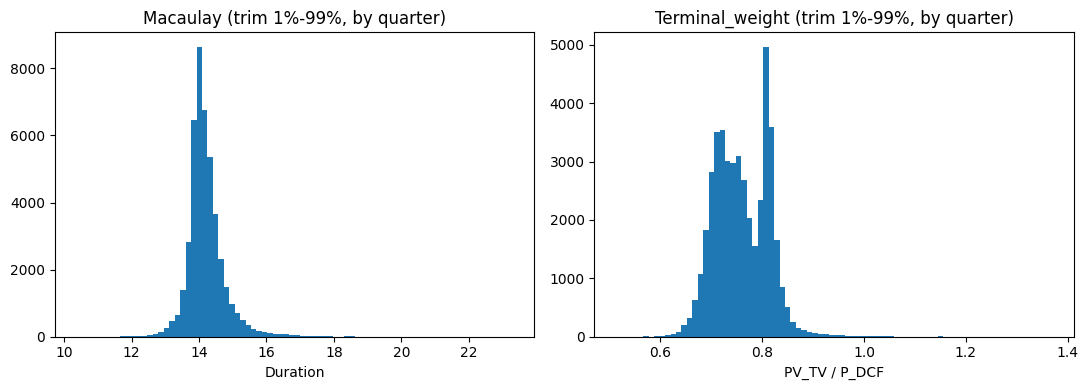

Cross-sectional std per quarter (Duration_DCF_Macaulay_trim):


count    109.000000
mean       0.546846
std        0.156998
min        0.322276
25%        0.421092
50%        0.523944
75%        0.626065
max        1.037137
Name: Duration_DCF_Macaulay_trim, dtype: float64

In [29]:
import matplotlib.pyplot as plt

ana = result.copy()
ana['is_ok'] = ana['status'].eq('ok')
n_total = len(ana)
n_ok = int(ana['is_ok'].sum())
n_bad = n_total - n_ok
cf_missing = ana[cf_cols].isna().any(axis=1)

quality = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_ok',
        'rows_invalid',
        'ok_share',
        'share_missing_any_CF',
        'share_invalid_pdcf_small_or_missing',
        'share_invalid_pdcf_extreme_high',
        'share_invalid_horizon_lt3',
        'share_invalid_growth_rule',
    ],
    'value': [
        n_total,
        n_ok,
        n_bad,
        n_ok / n_total if n_total else np.nan,
        float(cf_missing.mean()),
        float(ana['invalid_pdcf_small_or_missing'].mean()) if 'invalid_pdcf_small_or_missing' in ana.columns else np.nan,
        float(ana['invalid_pdcf_extreme_high'].mean()) if 'invalid_pdcf_extreme_high' in ana.columns else np.nan,
        float(ana['invalid_horizon_lt3'].mean()) if 'invalid_horizon_lt3' in ana.columns else np.nan,
        float(ana['invalid_growth_rule'].mean()) if 'invalid_growth_rule' in ana.columns else np.nan,
    ]
})

display(quality)

for col in ['Duration_DCF_Macaulay_trim']:
    if col in ana.columns:
        s = ana.loc[ana['is_ok'], col].dropna()
        print(f'{col} describe (ok only):')
        display(s.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

tw_t = ana.loc[ana['is_ok'], 'Terminal_weight_trim'].dropna() if 'Terminal_weight_trim' in ana.columns else pd.Series(dtype='float64')
print('Terminal_weight trimmed 1%-99% (within quarter) describe:')
display(tw_t.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

d_mac = ana.loc[ana['is_ok'], 'Duration_DCF_Macaulay_trim'].dropna() if 'Duration_DCF_Macaulay_trim' in ana.columns else pd.Series(dtype='float64')
ax[0].hist(d_mac, bins=80)
ax[0].set_title('Macaulay (trim 1%-99%, by quarter)')
ax[0].set_xlabel('Duration')

ax[1].hist(tw_t, bins=80)
ax[1].set_title('Terminal_weight (trim 1%-99%, by quarter)')
ax[1].set_xlabel('PV_TV / P_DCF')

plt.tight_layout()
plt.show()

if 'quarter' in ana.columns:
    for col in ['Duration_DCF_Macaulay_trim']:
        if col in ana.columns:
            cs_std_desc = (
                ana.loc[ana['is_ok'] & ana[col].notna()]
                .groupby('quarter')[col]
                .std()
                .describe()
            )
            print(f'Cross-sectional std per quarter ({col}):')
            display(cs_std_desc)



## 9) Analyse: Zeit- und Sektorstabilität

Hier prüfe ich, ob sich die Duration über Jahre sowie sektoral plausibel unterscheidet.


,year,n,p10,median,p90,mean
0,1998,284,13.820163,14.110932,14.724984,14.204233
1,1999,1196,13.772337,14.184345,14.730417,14.213344
2,2000,1283,13.647429,14.187198,14.938702,14.241765
3,2001,1355,13.661611,14.222562,15.057850,14.300023
4,2002,1363,13.789699,14.233844,15.043460,14.357713
5,2003,1368,13.700773,14.142787,14.976278,14.265922
6,2004,1432,13.692876,14.110741,14.700325,14.176888
7,2005,1424,13.720402,14.042220,14.505034,14.089265
8,2006,1517,13.723705,14.052273,14.574138,14.107536
9,2007,1630,13.719359,14.091397,14.566916,14.124851


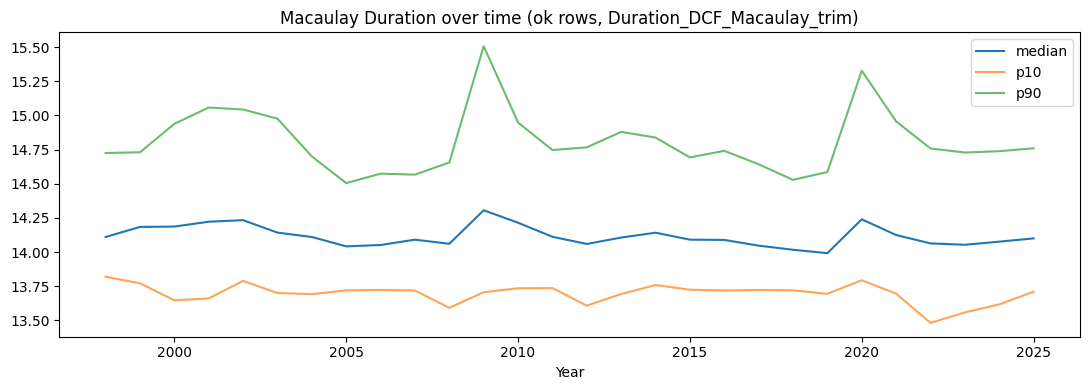

Sector stability skipped: required columns or file missing.


In [30]:
ana = result.copy()

if 'asof_date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['asof_date']).dt.year
elif 'date' in ana.columns:
    ana['year'] = pd.to_datetime(ana['date']).dt.year
else:
    ana['year'] = np.nan

ok = ana[ana['status'].eq('ok')].copy()
plot_col = 'Duration_DCF_Macaulay_trim' if 'Duration_DCF_Macaulay_trim' in ok.columns else 'Duration_DCF_Macaulay'

year_stats = ok.groupby('year')[plot_col].agg(
    n='count',
    p10=lambda x: x.quantile(0.10),
    median='median',
    p90=lambda x: x.quantile(0.90),
    mean='mean'
).reset_index()

display(year_stats.head(20))

fig, ax = plt.subplots(1, 1, figsize=(11, 4))
ax.plot(year_stats['year'], year_stats['median'], label='median')
ax.plot(year_stats['year'], year_stats['p10'], label='p10', alpha=0.7)
ax.plot(year_stats['year'], year_stats['p90'], label='p90', alpha=0.7)
ax.set_title(f'Macaulay Duration over time (ok rows, {plot_col})')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

sec_path = DATA_DIR / 'euro500_x_EPS.parquet'
if sec_path.exists() and all(c in ok.columns for c in ['RIC', 'quarter', 'asof_date']):
    sec = pd.read_parquet(sec_path)[['RIC', 'quarter', 'asof_date', 'trbc_sector']].copy()
    sec['asof_date'] = pd.to_datetime(sec['asof_date'])
    ok['asof_date'] = pd.to_datetime(ok['asof_date'])

    ok_sec = ok.merge(
        sec.drop_duplicates(['RIC', 'quarter', 'asof_date']),
        on=['RIC', 'quarter', 'asof_date'],
        how='left'
    )
    sec_stats = (
        ok_sec.groupby('trbc_sector')[plot_col]
        .agg(n='count', median='median', mean='mean')
        .sort_values('median', ascending=False)
    )
    display(sec_stats.head(15))
else:
    print('Sector stability skipped: required columns or file missing.')



## 10) Analyse: Einfacher Zins-Shock-Test (Long HighD - Short LowD)

Idee:
- bilde je Quartal Duration-Quintile
- konstruiere Long-Short-Rendite $Q5-Q1$
- regressiere auf tägliche Änderung des 2Y OIS (`dy`)

Interpretation:
- ein negativer `dy`-Koeffizient ist konsistent mit höherer Zinssensitivität von High-Duration-Aktien.


In [31]:
rets_path = DATA_DIR / 'daily_returns_euro500.parquet'
ois_path = DATA_DIR / 'rates_2yOIS_daily.parquet'

if not (rets_path.exists() and ois_path.exists()):
    print('Missing required files for shock test.')
else:
    rets = pd.read_parquet(rets_path)[['date', 'quarter', 'RIC', 'ret']].copy()
    rets['date'] = pd.to_datetime(rets['date'])
    rets['ret'] = pd.to_numeric(rets['ret'], errors='coerce')

    ois = pd.read_parquet(ois_path).copy()
    ois['date'] = pd.to_datetime(ois['date'])
    ois['dy'] = pd.to_numeric(ois['dy'], errors='coerce')

    def run_ls_shock_test(dur_col: str, label: str):
        if dur_col not in result.columns:
            print(f'Skipping {label}: column not found -> {dur_col}')
            return

        dur_q = result[result['status'].eq('ok')][['RIC', 'quarter', dur_col]].copy()
        dur_q[dur_col] = pd.to_numeric(dur_q[dur_col], errors='coerce')
        dur_q = dur_q.dropna().drop_duplicates(['RIC', 'quarter'])
        if dur_q.empty:
            print(f'Skipping {label}: empty duration sample after dropna.')
            return

        dur_q['q'] = dur_q.groupby('quarter')[dur_col].transform(
            lambda s: pd.qcut(s.rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
        )

        q_check = (
            dur_q.groupby('q', observed=False)[dur_col]
            .median()
            .rename('median_duration')
            .reset_index()
        )
        print(f'Quintile median durations ({label}):')
        display(q_check)

        px = rets.merge(dur_q[['RIC', 'quarter', 'q']], on=['RIC', 'quarter'], how='inner')
        px = px.dropna(subset=['ret', 'q'])

        q_daily = px.groupby(['date', 'q'])['ret'].mean().reset_index()
        q_wide = q_daily.pivot(index='date', columns='q', values='ret')

        required_q = {1, 5}
        if not required_q.issubset(set(q_wide.columns.tolist())):
            print(f'Skipping {label}: need q=1 and q=5, have {sorted(q_wide.columns.tolist())}')
            return

        q_wide['LS_5m1'] = q_wide[5] - q_wide[1]

        reg = q_wide[['LS_5m1']].merge(
            ois[['date', 'dy']].set_index('date'),
            left_index=True,
            right_index=True,
            how='inner'
        )
        reg['LS_5m1'] = pd.to_numeric(reg['LS_5m1'], errors='coerce')
        reg['dy'] = pd.to_numeric(reg['dy'], errors='coerce')
        reg = reg.dropna(subset=['LS_5m1', 'dy']).copy()

        if reg.empty:
            print(f'Skipping {label}: no overlap with OIS dy.')
            return

        # raw OLS summary
        y = reg['LS_5m1'].to_numpy(dtype=float)
        x = reg['dy'].to_numpy(dtype=float)
        X = np.column_stack([np.ones(len(x), dtype=float), x])
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        yhat = X @ beta
        resid = y - yhat
        n = len(y)
        k = X.shape[1]
        s2 = (resid @ resid) / max(n - k, 1)
        vcov = s2 * np.linalg.inv(X.T @ X)
        se = np.sqrt(np.diag(vcov))
        tvals = beta / se
        out_raw = pd.DataFrame({'coef': beta, 'std_err': se, 't_value': tvals}, index=['const', 'dy'])

        # HAC robustness
        import statsmodels.api as sm
        m_raw = sm.OLS(y, X).fit()
        m_raw_hac = m_raw.get_robustcov_results(cov_type='HAC', maxlags=5)
        out_hac = pd.DataFrame({
            'coef_raw': m_raw_hac.params,
            'se_raw_HAC': m_raw_hac.bse,
            't_raw_HAC': m_raw_hac.tvalues,
        }, index=['const', 'dy'])

        slope = float(m_raw_hac.params[1])
        slope_bp = slope * 1e-4

        print(f'Regression ({label}): LS_5m1 ~ const + dy')
        print('n_obs:', n)
        print('Average LS_5m1 daily return:', reg['LS_5m1'].mean())
        print('Std(dy):', reg['dy'].std(), '| Std(LS_5m1):', reg['LS_5m1'].std())
        print('Slope interpretation: +1 bp dy ->', slope_bp, 'change in LS_5m1')
        print('Classic OLS:')
        display(out_raw)
        print('HAC(Newey-West, maxlags=5):')
        display(out_hac)

    # Run shock test for Macaulay duration
    run_ls_shock_test('Duration_DCF_Macaulay_trim', 'Macaulay Trimmed')



Quintile median durations (Macaulay Trimmed):


,q,median_duration
0,1,13.693003
1,2,13.940991
2,3,14.105955
3,4,14.330890
4,5,14.793131


Regression (Macaulay Trimmed): LS_5m1 ~ const + dy
n_obs: 4224
Average LS_5m1 daily return: -3.9547920456489206e-05
Std(dy): 0.03529501185727414 | Std(LS_5m1): 0.005104912039910755
Slope interpretation: +1 bp dy -> 9.440648354939007e-07 change in LS_5m1
Classic OLS:


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_94741/1736654504.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  q_daily = px.groupby(['date', 'q'])['ret'].mean().reset_index()


,coef,std_err,t_value
const,-0.000042,0.000078,-0.530031
dy,0.009441,0.002221,4.250237


HAC(Newey-West, maxlags=5):


,coef_raw,se_raw_HAC,t_raw_HAC
const,-0.000042,0.000081,-0.512586
dy,0.009441,0.003253,2.902556


## 11) Fazit und Lesart der Duration

Wenn `Duration_DCF_Macaulay` steigt, verschiebt sich der wertrelevante Teil der Earnings zeitlich nach hinten.

Ökonomisch heißt das:
- höhere Abhängigkeit vom Terminalanteil
- stärkere Exponierung gegenüber Änderungen in Zinsen und langfristigen Erwartungen
- bei konstantem Diskontsatz wird primär ein **Timing-Effekt** gemessen
